<a href="https://colab.research.google.com/github/Prajkta11222/cnn-architecture-comparison-cifar10/blob/main/Evaluation_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CNN Architecture Comparison
## Evaluation, Analysis and Visualization

This notebook combines the results obtained from LeNet, AlexNet, VGG-11 and ResNet-18 trained on the CIFAR-10 dataset.

The main objective is to compare the models based on accuracy, number of parameters and training time.

In [ ]:
# Import required libraries for data handling and visualization
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Store the actual experimental results obtained from Person 1 and Person 2
# No sample or assumed values are usedmodels_list = ['LeNet', 'AlexNet', 'VGG-11', 'ResNet-18']

params = [
    62006,
    35855178,
    128807306,
    11181642
]

accuracy = [
    64.62,
    76.01,
    10.00,
    76.75
]

training_time = [
    201.05,
    446.36,
    947.16,
    478.17
]

In [ ]:
# Create a DataFrame containing the final experimental results
data = {
    'Model': models_list,
    'Parameters': params,
    'Test Accuracy (%)': accuracy,
    'Training Time (seconds)': training_time
}

df = pd.DataFrame(data)

print(df)

       Model  Parameters  Test Accuracy (%)  Training Time (seconds)
0      LeNet       62006              64.62                   201.05
1    AlexNet    35855178              76.01                   446.36
2     VGG-11   128807306              10.00                   947.16
3  ResNet-18    11181642              76.75                   478.17


In [ ]:
# Save the final comparison table as a CSV file for the report and GitHub repository
df.to_csv('results_table.csv', index=False)

print("results_table.csv saved successfully!")

results_table.csv saved successfully!


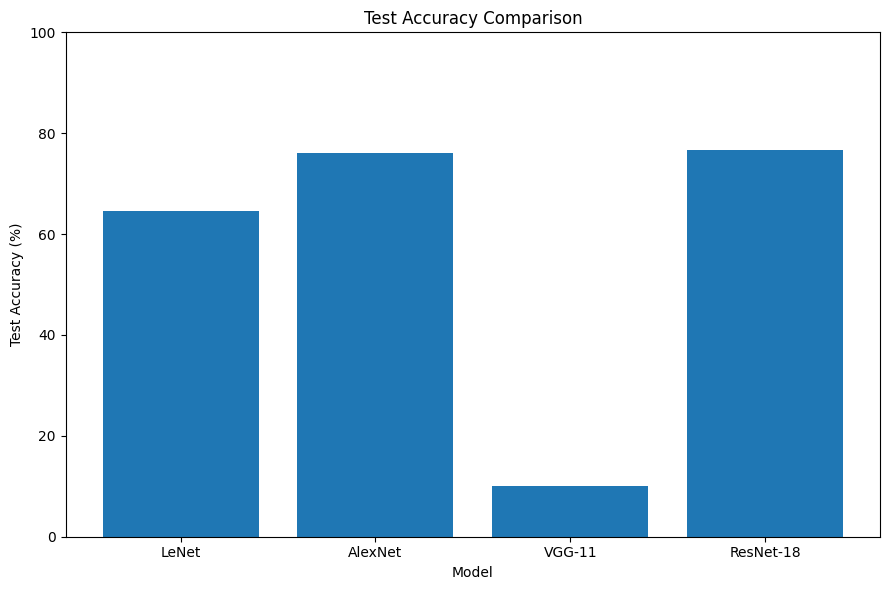

In [ ]:
# Compare the test accuracy achieved by all four CNN architectures
plt.figure(figsize=(9, 6))

plt.bar(models_list, accuracy)

plt.xlabel("Model")
plt.ylabel("Test Accuracy (%)")
plt.title("Test Accuracy Comparison")

plt.ylim(0, 100)

plt.tight_layout()
plt.savefig("accuracy_comparison.png", dpi=300)

plt.show()

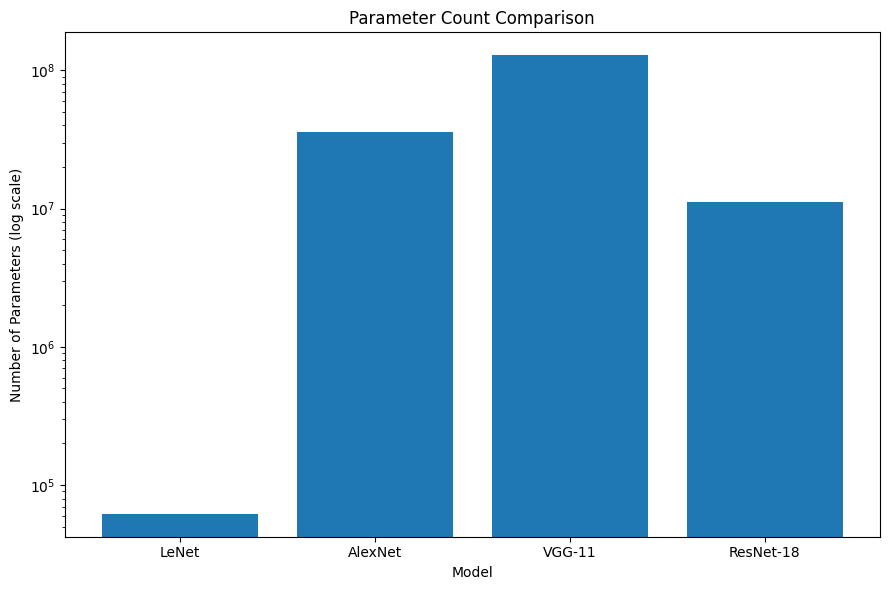

In [ ]:
# Compare the number of trainable parameters in each architecture
# Log scale is used because the parameter counts differ greatly
plt.figure(figsize=(9, 6))

plt.bar(models_list, params)

plt.yscale("log")

plt.xlabel("Model")
plt.ylabel("Number of Parameters (log scale)")
plt.title("Parameter Count Comparison")

plt.tight_layout()
plt.savefig("parameter_comparison.png", dpi=300)

plt.show()

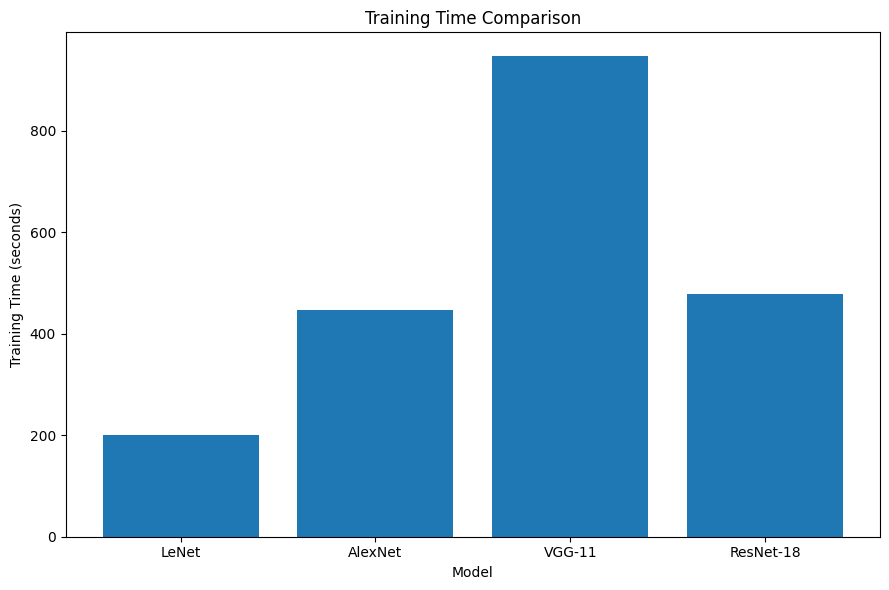

In [ ]:
# Compare the training time required by each CNN architecture
plt.figure(figsize=(9, 6))

plt.bar(models_list, training_time)

plt.xlabel("Model")
plt.ylabel("Training Time (seconds)")
plt.title("Training Time Comparison")

plt.tight_layout()
plt.savefig("training_time_comparison.png", dpi=300)

plt.show()

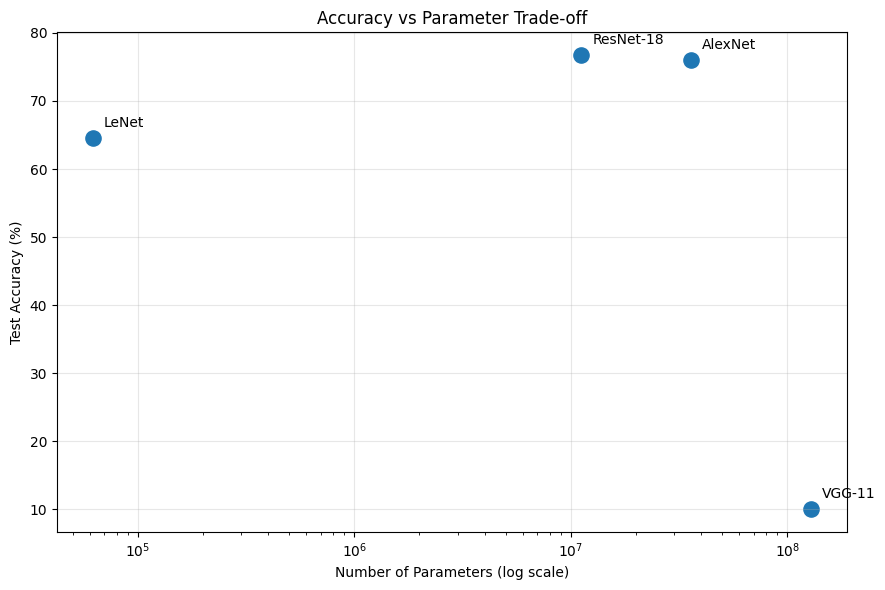

In [ ]:
# Analyze the trade-off between test accuracy and model parameter count
# Log scale is used because model sizes vary significantly
plt.figure(figsize=(9, 6))

plt.scatter(params, accuracy, s=120)

for i, model in enumerate(models_list):
    plt.annotate(
        model,
        (params[i], accuracy[i]),
        xytext=(8, 8),
        textcoords="offset points"
    )

plt.xscale("log")

plt.xlabel("Number of Parameters (log scale)")
plt.ylabel("Test Accuracy (%)")
plt.title("Accuracy vs Parameter Trade-off")

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("accuracy_vs_parameters.png", dpi=300)

plt.show()

In [ ]:
# Calculate a supplementary parameter-efficiency measure
# This represents accuracy relative to the number of model parameters
df["Parameters (Millions)"] = df["Parameters"] / 1_000_000

df["Accuracy per Million Parameters"] = (
    df["Test Accuracy (%)"] / df["Parameters (Millions)"]
)

print(df)

       Model  Parameters  Test Accuracy (%)  Training Time (seconds)  \
0      LeNet       62006              64.62                   201.05   
1    AlexNet    35855178              76.01                   446.36   
2     VGG-11   128807306              10.00                   947.16   
3  ResNet-18    11181642              76.75                   478.17   

   Parameters (Millions)  Accuracy per Million Parameters  
0               0.062006                      1042.157211  
1              35.855178                         2.119917  
2             128.807306                         0.077635  
3              11.181642                         6.863929  


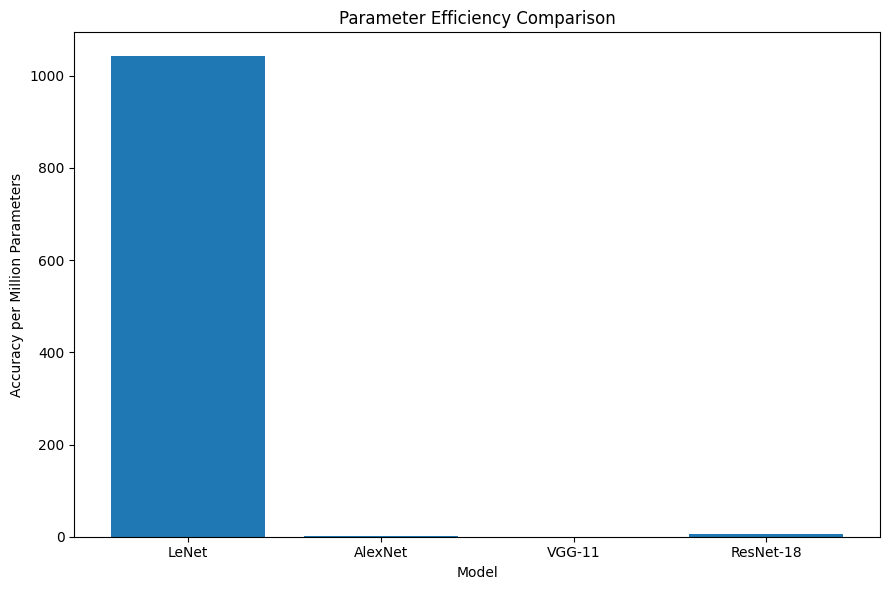

In [ ]:
# Visualize the supplementary parameter-efficiency comparison
plt.figure(figsize=(9, 6))

plt.bar(
    models_list,
    df["Accuracy per Million Parameters"]
)

plt.xlabel("Model")
plt.ylabel("Accuracy per Million Parameters")
plt.title("Parameter Efficiency Comparison")

plt.tight_layout()
plt.savefig("parameter_efficiency.png", dpi=300)

plt.show()

In [ ]:
# Display the complete final comparison table for analysis and report preparation
print("FINAL CNN ARCHITECTURE COMPARISON")
print("=" * 70)

display(df)

FINAL CNN ARCHITECTURE COMPARISON


,Model,Parameters,Test Accuracy (%),Training Time (seconds),Parameters (Millions),Accuracy per Million Parameters
0,LeNet,62006,64.62,201.05,0.062006,1042.157211
1,AlexNet,35855178,76.01,446.36,35.855178,2.119917
2,VGG-11,128807306,10.00,947.16,128.807306,0.077635
3,ResNet-18,11181642,76.75,478.17,11.181642,6.863929


In [ ]:
# Identify the model with the highest test accuracy
best_accuracy_model = df.loc[
    df["Test Accuracy (%)"].idxmax()
]

print("Highest Accuracy Model:")
print(best_accuracy_model)

Highest Accuracy Model:
Model                              ResNet-18
Parameters                          11181642
Test Accuracy (%)                      76.75
Training Time (seconds)               478.17
Parameters (Millions)              11.181642
Accuracy per Million Parameters     6.863929
Name: 3, dtype: object


In [ ]:
# Identify the model with the smallest number of parameters
smallest_model = df.loc[
    df["Parameters"].idxmin()
]

print("Smallest Model:")
print(smallest_model)

Smallest Model:
Model                                    LeNet
Parameters                               62006
Test Accuracy (%)                        64.62
Training Time (seconds)                 201.05
Parameters (Millions)                 0.062006
Accuracy per Million Parameters    1042.157211
Name: 0, dtype: object


In [ ]:
# Identify the model with the shortest training time
fastest_model = df.loc[
    df["Training Time (seconds)"].idxmin()
]

print("Fastest Training Model:")
print(fastest_model)

Fastest Training Model:
Model                                    LeNet
Parameters                               62006
Test Accuracy (%)                        64.62
Training Time (seconds)                 201.05
Parameters (Millions)                 0.062006
Accuracy per Million Parameters    1042.157211
Name: 0, dtype: object


In [ ]:
# Save the complete final results including calculated efficiency metrics
df.to_csv(
    "final_cnn_comparison_results.csv",
    index=False
)

print("Final results saved successfully!")

Final results saved successfully!


# Comparative Analysis

LeNet achieved a test accuracy of 64.62% with only 62,006 parameters, making it the most lightweight and fastest model among the four architectures.

AlexNet achieved 76.01% test accuracy with 35,855,178 parameters. It provided substantially higher accuracy than LeNet but required considerably more parameters and training time.

VGG-11 contained the largest number of parameters at 128,807,306 and required the longest training time of 947.16 seconds. However, its recorded test accuracy was only 10%. This indicates that VGG-11 did not learn the CIFAR-10 classification task effectively under the given experimental setup.

ResNet-18 achieved the highest recorded accuracy of 76.75% with 11,181,642 parameters. It therefore achieved slightly higher accuracy than AlexNet while using substantially fewer parameters.

Overall, the results demonstrate that increasing the number of parameters does not necessarily guarantee better accuracy. ResNet-18 provided the strongest accuracy result among the four models while maintaining a substantially smaller parameter count than AlexNet and VGG-11.

# Conclusion

The experiment compared LeNet, AlexNet, VGG-11, and ResNet-18 on the CIFAR-10 dataset using the recorded test accuracy, parameter count, and training time.

LeNet was the most lightweight and fastest architecture, but its accuracy was lower than the deeper models.

AlexNet achieved a significant improvement in accuracy but required a much larger number of parameters.

VGG-11 had the largest parameter count and longest training time, but its recorded 10% accuracy indicates that it was not effective under the given training configuration.

ResNet-18 achieved the highest test accuracy of 76.75% while using only 11.18 million parameters. Based on the recorded results, ResNet-18 provides the most favorable balance between accuracy and parameter count among the four tested architectures.

The experiment shows that model efficiency depends not only on the number of parameters but also on the architecture and training behavior.